In [1]:
%reload_ext autoreload
%autoreload 2
import sys
from pathlib import Path
from typing import Any, Optional

# Add benchmark-app to the path so we can import bench modules
BENCHMARK_APP_DIR = Path("__file__").resolve().parent.parent
if str(BENCHMARK_APP_DIR) not in sys.path:
    sys.path.insert(0, str(BENCHMARK_APP_DIR))
BASELINES_DIR = BENCHMARK_APP_DIR / "baselines-results"

In [2]:
import matplotlib.pyplot as plt

import plot_utils

%matplotlib inline
plt.rcParams.update({"figure.figsize": (10, 6), "font.size": 12, "pdf.fonttype": 42})

In [3]:
from bench.custom_bench.stats import BenchmarkStats
from bench.params import QECParams

In [4]:
def load_stats(
    *,
    qec_params: QECParams,
    decoders_name_with_kwargs: list[tuple[str, dict[str, Any]]],
    physical_error_rates: list[float],
) -> list[BenchmarkStats]:
    subdir = (
        BASELINES_DIR
        / f"{qec_params.code}_{qec_params.noise_model}"
        / f"d={qec_params.d}_rounds={qec_params.rounds}_basis={qec_params.basis}"
    )
    filtered_stats: list[BenchmarkStats] = []
    for decoder_name, decoder_kwargs in decoders_name_with_kwargs:
        csv_path = subdir / decoder_name / "custom_benchmark.csv"
        all_stats = BenchmarkStats.load_csv(csv_path)
        for s in all_stats:
            m = s.metadata
            if m.p not in physical_error_rates:
                continue
            if m.decoder_params != decoder_kwargs:
                continue
            filtered_stats.append(s)
    return filtered_stats

In [ ]:
def plot_iter_cdf(
    stats: list[BenchmarkStats],
    *,
    qec_params: QECParams,
    suptitle: Optional[str] = None,
    save_at: Optional[str | Path] = None,
):
    fig, ax = plt.subplots()
    plot_utils.plot_iter_cdf(
        stats,
        ax,
        min_iter=100,
        label_fn=lambda s: s.metadata.decoder_name,
        title=f"{qec_params.code}, {qec_params.noise_model}",
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=plot_utils.SUPTITLE_FONTSIZE)
    fig.tight_layout()
    if save_at:
        fig.savefig(save_at)
    plt.show()

# 1. Gross code, Circuit-level

In [6]:
qec_params = QECParams(
    code="BB_144_12_12", noise_model="CircuitLevel", d=12, rounds=12, basis="Z"
)
physical_error_rate = 0.001
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.2}
relaybp_kwargs = {
    "gamma0": 0.2,
    "gamma_dist_interval": [-0.19806670996164882, 0.6200937872049607],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}
# relaybp_kwargs = {
#     "gamma0": 0.125,
#     "gamma_dist_interval": [-0.24, 0.66],
#     "num_relays": 300,
#     "pre_iter": 80,
#     "max_iter_per_relay": 60,
#     "stop_nconv": 1,
#     "num_indep_decoders": 1,
# }

In [7]:
loaded_stats = load_stats(
    qec_params=qec_params,
    decoders_name_with_kwargs=[
        ("BP", bp_kwargs),
        ("MemBP", membp_kwargs),
        ("RelayBP", relaybp_kwargs),
    ],
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

Loaded 3 benchmark entries


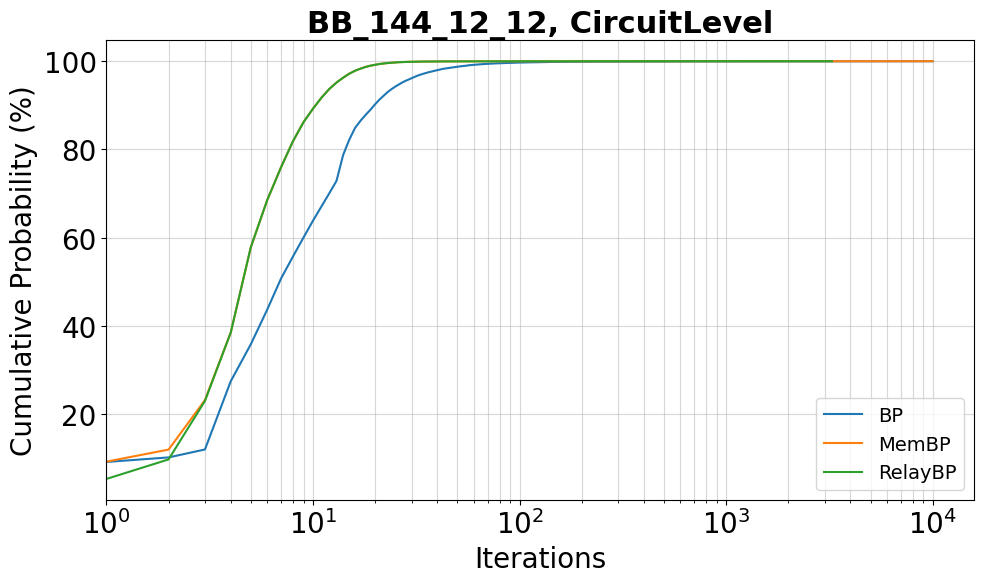

In [8]:
plot_iter_cdf(loaded_stats, qec_params=qec_params)

# 2. Rotated surface code d=11, Circuit-level

In [9]:
qec_params = QECParams(
    code="RotatedSurfaceCode", noise_model="CircuitLevel", d=11, rounds=11, basis="Z"
)
physical_error_rate = 0.001
bp_kwargs = {"max_iter": 10000}
membp_kwargs = {"max_iter": 10000, "gamma": 0.55}
relaybp_kwargs = {
    "gamma0": 0.55,
    "gamma_dist_interval": [-0.2526669073577039, 0.9575754453501071],
    "num_relays": 64,
    "pre_iter": 50,
    "max_iter_per_relay": 50,
    "stop_nconv": 1,
    "num_indep_decoders": 1,
}

In [10]:
loaded_stats = load_stats(
    qec_params=qec_params,
    decoders_name_with_kwargs=[
        ("BP", bp_kwargs),
        ("MemBP", membp_kwargs),
        ("RelayBP", relaybp_kwargs),
    ],
    physical_error_rates=[physical_error_rate],
)
print(f"Loaded {len(loaded_stats)} benchmark entries")

Loaded 3 benchmark entries


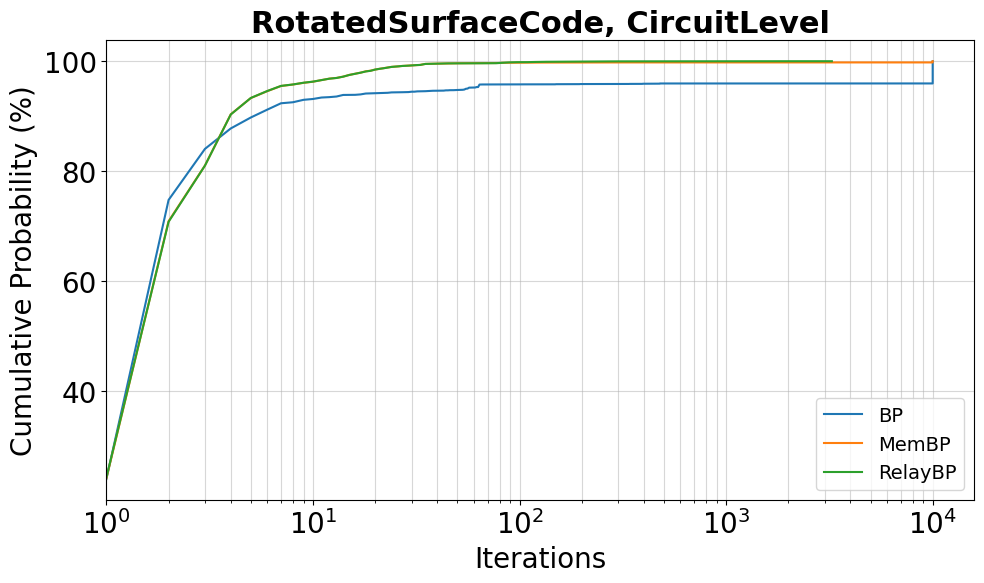

In [11]:
plot_iter_cdf(loaded_stats, qec_params=qec_params)